In [8]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
dsetname = "studentmath"
dsetnamex = "Student-mat "
d = 30

#######
graphsx = np.load("../graphs/"+dsetname+"_knn_random.npy", allow_pickle=True)


## Info on the graphs

In [3]:
######
randomgraphsinfo = pd.read_csv("../graphs/studentmath_knn_graphsummary.npy")
randomgraphsinfo


,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Student-math (30),1,206,35,16,19,1.0,0.514563,0.485437,5.885714,0.037367,0.022638,0.014729,106,100,0,0,0
1,Student-math (30),2,206,38,17,21,2.0,1.038835,0.961165,10.842105,0.167274,0.097229,0.070045,60,52,0,0,1
2,Student-math (30),3,206,39,17,22,3.0,1.461165,1.538835,15.846154,0.383282,0.185982,0.197300,21,30,0,0,2
3,Student-math (30),4,206,39,17,22,4.0,2.014563,1.985437,21.128205,0.659910,0.333696,0.326214,13,14,0,0,3
4,Student-math (30),5,206,39,17,22,5.0,2.582524,2.417476,26.410256,1.014255,0.532228,0.482027,5,8,0,0,4
5,Student-math (30),6,206,39,17,22,6.0,3.053398,2.946602,31.692308,1.459531,0.742884,0.716647,5,6,0,0,5
6,Student-math (30),7,206,39,17,22,7.0,3.645631,3.354369,36.974359,1.950225,1.036088,0.914137,1,2,0,0,6
7,Student-math (30),8,206,39,17,22,8.0,4.184466,3.815534,42.256410,2.470613,1.343263,1.127350,0,1,0,0,7
8,Student-math (30),9,206,39,17,22,9.0,4.757282,4.242718,47.538462,3.082216,1.719204,1.363012,0,0,0,0,8
9,Student-math (30),10,206,39,17,22,10.0,5.271845,4.728155,52.820513,3.762160,2.094956,1.667203,0,0,0,0,9


## Learning

In [4]:
summary_dfx = scripts.algorithms.learn_greedy(datagraphs=graphsx, 
                                               dim=d,
                                               savedname=dsetname,
                                               thresh=False)

summary_dfx.to_csv("./ls_results/"+dsetname+"_learn_results_knn.csv", index=False)
summary_dfx.head(10)

,K,dataset,graphid,kmax,n,m,tr_utility,ts_utility,tr_size,ts_size,...,ts_only-Ns,tr_empty_adj,ts_empty_adj,tr_perf1,ts_perf1,tr_perf2,ts_perf2,tr_perf3,ts_perf3,greedyTime
0,1,studentmath (30),0,1,206,35,74.230,31.770,144.0,62.0,...,30.23,0.0,0.0,100.00000,100.00000,51.54855,51.24198,0.00000,0.00000,0.016932
1,2,studentmath (30),0,1,206,35,74.230,31.770,144.0,62.0,...,30.23,0.0,0.0,100.00000,100.00000,51.54855,51.24198,0.00000,0.00000,0.016034
2,3,studentmath (30),0,1,206,35,74.230,31.770,144.0,62.0,...,30.23,0.0,0.0,100.00000,100.00000,51.54855,51.24198,0.00000,0.00000,0.016601
3,4,studentmath (30),0,1,206,35,74.230,31.770,144.0,62.0,...,30.23,0.0,0.0,100.00000,100.00000,51.54855,51.24198,0.00000,0.00000,0.016642
4,5,studentmath (30),0,1,206,35,74.230,31.770,144.0,62.0,...,30.23,0.0,0.0,100.00000,100.00000,51.54855,51.24198,0.00000,0.00000,0.016412
5,1,studentmath (30),1,2,206,38,82.445,34.475,144.0,62.0,...,15.82,0.0,0.0,76.46771,74.65585,57.25349,55.60484,61.33031,58.79616,0.030275
6,2,studentmath (30),1,2,206,38,87.950,36.955,144.0,62.0,...,15.82,0.0,0.0,81.57222,80.03497,61.07639,59.60480,69.71019,67.52656,0.059354
7,3,studentmath (30),1,2,206,38,91.355,37.980,144.0,62.0,...,15.82,0.0,0.0,84.72959,82.25361,63.44098,61.25807,74.90073,71.07969,0.084884
8,4,studentmath (30),1,2,206,38,94.000,38.700,144.0,62.0,...,15.82,0.0,0.0,87.18252,83.80578,65.27777,62.41936,78.93377,73.59191,0.111941
9,5,studentmath (30),1,2,206,38,96.305,39.335,144.0,62.0,...,15.82,0.0,0.0,89.32040,85.17417,66.87849,63.44360,82.44716,75.81045,0.140265


## Plots

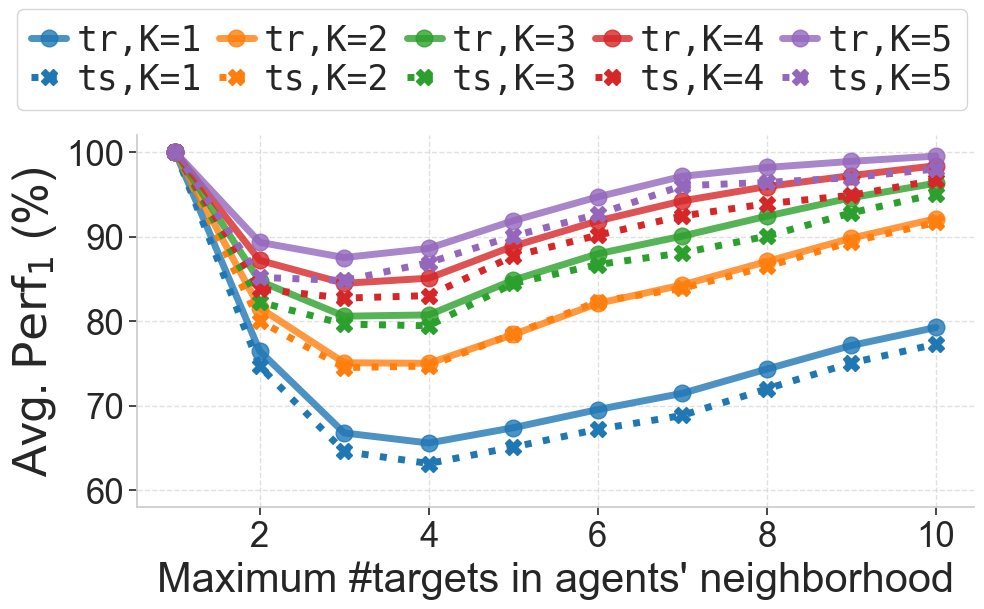

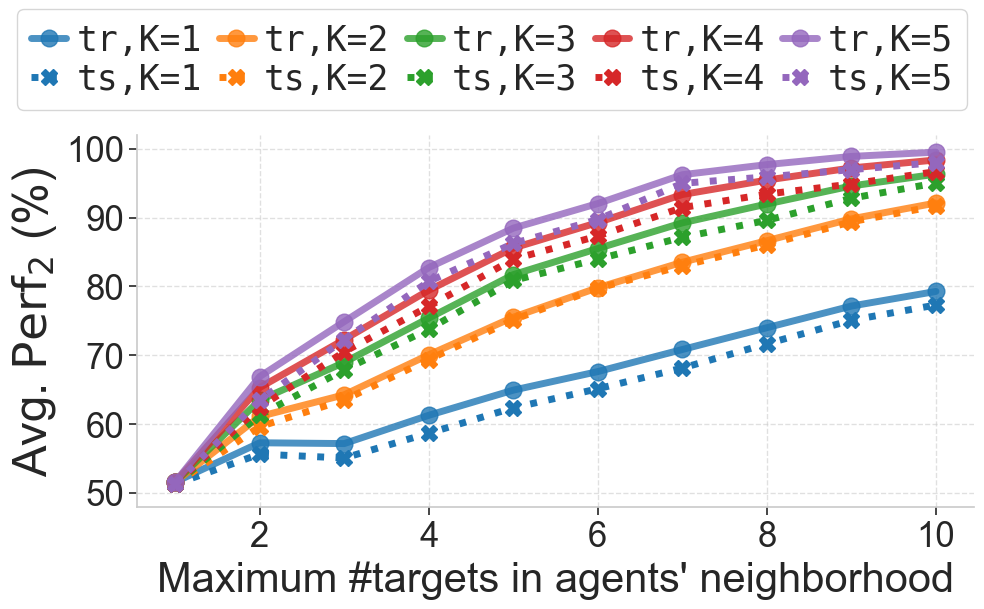

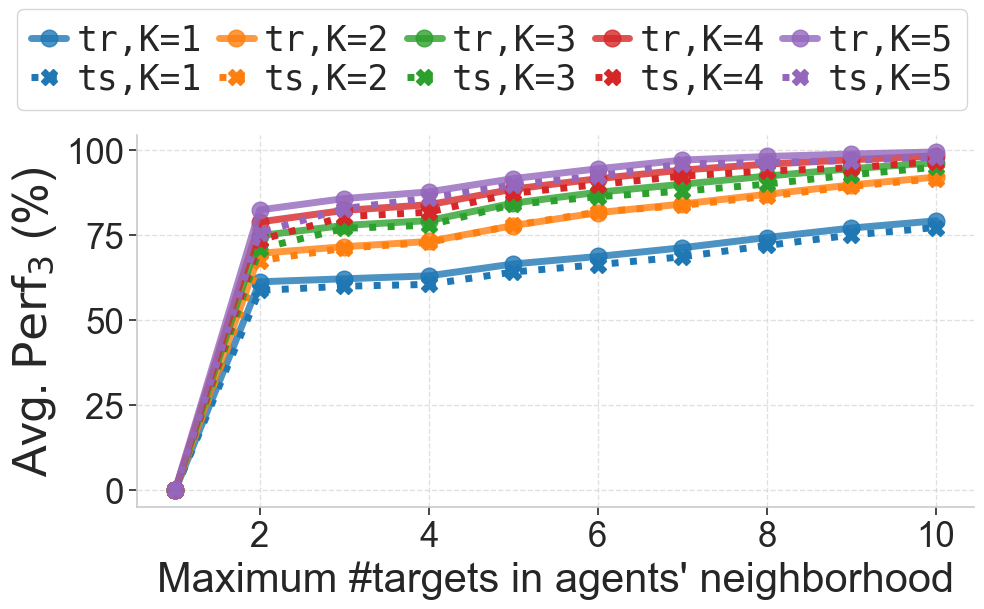

In [9]:
######### exclude: no neighbors and exclusively neg neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf1", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf1.pdf")

######### exclude: none
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf2", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf2.pdf")

######### exclude: no neighbors and exclusively neg/pos neighbors
scripts.analytics.learnsetting_plot(summary_res=summary_dfx,
                  thresh=False, 
                  perfv="perf3", 
                  save_as="./ls_results/figures/"+dsetname+"_learn_both_results_knn_perf3.pdf")

